#Books selling

##1.Genral cleaning

In [1]:
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime

In [4]:
# Read csv file into a pandas dataframe
df = pd.read_csv("Kaggle_Books-Selling-Records-.csv")
# Take a look at the first few rows
df.head(2)

,ID,Purchase-date,Date,Time,Quarter,Qtr,Year,Month,Date.1,Special Day,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1,2018-01-01T08:57:53+00:00,1/1/2018,8:57 AM,2018 - Q1,1,2018,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2018-01-02T02:04:01+00:00,1/2/2018,2:04 AM,2018 - Q1,1,2018,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df[df.duplicated()]

,ID,Purchase-date,Date,Time,Quarter,Qtr,Year,Month,Date.1,Special Day,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67


so, we do not have a duplicate elements

In [6]:
df.shape

(3480, 68)

In [7]:
df=df.T.drop_duplicates().T

In [8]:
columns_to_delete = ['Purchase-date','Quarter','Qtr','Year','Month','Date.1','Special Day','Day','Gender','Item-Status','Ship-State','Total_\namount','Currency','Unnamed: 36','Profit (INR)']
df=df.drop(columns=columns_to_delete)

In [9]:
df.head(1)

,ID,Date,Time,Online Sale Offers,Weekend,Morning,Afternoon,Evening,Night,Customer ID,...,Quantity,Item Price,Shipping-Price,Ship-City,Ship-Postal-Code,Category,Author,Publication,Profit Percentage\n (%),Cost Price
0,1,1/1/2018,8:57 AM,1,0,1,0,0,0,B07FWXWZT,...,1,999.0,85.0,Hyderabad,500073,college,Avi Silberschatz,McGraw-Hill,13,869.13


In [10]:
df.head(1)

,ID,Date,Time,Online Sale Offers,Weekend,Morning,Afternoon,Evening,Night,Customer ID,...,Quantity,Item Price,Shipping-Price,Ship-City,Ship-Postal-Code,Category,Author,Publication,Profit Percentage\n (%),Cost Price
0,1,1/1/2018,8:57 AM,1,0,1,0,0,0,B07FWXWZT,...,1,999.0,85.0,Hyderabad,500073,college,Avi Silberschatz,McGraw-Hill,13,869.13


In [11]:
df.shape

(3480, 22)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3480 entries, 0 to 3479
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      3480 non-null   object
 1   Date                    3480 non-null   object
 2   Time                    3480 non-null   object
 3   Online Sale Offers      3480 non-null   object
 4   Weekend                 3480 non-null   object
 5   Morning                 3480 non-null   object
 6   Afternoon               3480 non-null   object
 7   Evening                 3480 non-null   object
 8   Night                   3480 non-null   object
 9   Customer ID             3480 non-null   object
 10  Gender
F=1665
M=1815    3480 non-null   object
 11  Product-Name            3480 non-null   object
 12  Quantity                3480 non-null   object
 13  Item Price              3480 non-null   object
 14  Shipping-Price          3480 non-null   object
 15  Ship

check for missing value


In [13]:
df.isna().sum()

ID                         0
Date                       0
Time                       0
Online Sale Offers         0
Weekend                    0
Morning                    0
Afternoon                  0
Evening                    0
Night                      0
Customer ID                0
Gender\nF=1665\nM=1815     0
Product-Name               0
Quantity                   0
Item Price                 0
Shipping-Price             0
Ship-City                  0
Ship-Postal-Code           0
Category                   0
Author                     0
Publication                0
Profit Percentage\n (%)    0
Cost Price                 0
dtype: int64

now we are going to check for the outlier

In [14]:
# calculate the IQR
q1=df['Cost Price'].quantile(0.25)
q3=df['Cost Price'].quantile(0.75)
IQR=q3-q1

# Identify outliers
outliers_mask = ((df['Cost Price']<(q1-1.5*IQR)) | (df['Cost Price']>(q3+1.5*IQR)))
outliers = df['Cost Price'][outliers_mask]

print("the number of outliers: "+ str(len(outliers)))
print("the max outlier value: "+ str(outliers.max()))
print("the min outlier value: "+ str(outliers.min()))

# Filter out outliers
df = df[~outliers_mask].reset_index(drop=True)

the number of outliers: 68
the max outlier value: 5611.5
the min outlier value: 1026.6


In [15]:

length_before = len(df)

# تم حذف القيم المتطرفة بالفعل في الخلية السابقة
print("تم حذف القيم المتطرفة بنجاح.")

length_after = len(df)
print(df)


تم حذف القيم المتطرفة بنجاح.
        ID        Date      Time Online Sale Offers  Weekend Morning  \
0        1    1/1/2018   8:57 AM                   1       0       1   
1        2    1/2/2018   2:04 AM                   1       0       0   
2        3    1/3/2018   5:08 AM                   1       0       0   
3        4    1/4/2018   4:06 PM                   1       0       0   
4        5    1/4/2018   8:12 PM                   0       0       0   
...    ...         ...       ...                 ...     ...     ...   
3407  3476  12/31/2019  12:02 PM                   1       0       0   
3408  3477  12/31/2019   2:53 AM                   1       0       0   
3409  3478  12/31/2019   6:02 AM                   1       0       1   
3410  3479  12/31/2019   7:28 AM                   1       0       1   
3411  3480  12/31/2019   9:06 AM                   1       0       1   

     Afternoon Evening Night Customer ID  ... Quantity Item Price  \
0            0       0     0   B07FWX

adjust

In [16]:
# replace the value 'School' with 'school' in the 'Category' column
df['Category'] = df['Category'].replace('School', 'school')

now the data is clean

##2. data visualization and summery statistics

In [17]:
summary=df.describe()
summary

,ID,Date,Time,Online Sale Offers,Weekend,Morning,Afternoon,Evening,Night,Customer ID,...,Quantity,Item Price,Shipping-Price,Ship-City,Ship-Postal-Code,Category,Author,Publication,Profit Percentage\n (%),Cost Price
count,3412,3412,3412,3412,3412,3412,3412,3412,3412,3412,...,3412,3412.0,3412.0,3412,3412,3412,3412,3412,3412,3412.00
unique,3412,719,1135,2,2,2,2,2,2,2731,...,5,199.0,80.0,922,1517,3,173,122,3,235.00
top,1,4/7/2019,4:00 PM,0,0,0,0,0,0,B07FWVUVY,...,1,395.0,67.0,NEW DELHI,122001,school,NCERT,National Council of Education Research and Tra...,18,327.85
freq,1,48,13,2945,3074,2333,2458,2814,2631,8,...,3322,247.0,790.0,202,38,1859,1598,1341,1859,246.00


###1. customer behavior

In [18]:
##s = df.sort('Shipping-Price', descending=True)
#a = s.sort('Ship-City', distinct=True)
#a.barh('Shipping-Price', 'Ship-City')

In [19]:
# used to count the occurrences of each unique value in the 'Product-Name' column
name_counts = df['Product-Name'].value_counts()
print(name_counts)

Product-Name
Lakshya Rajasthan Ki Kala, Sanskriti Va Itihas 2019 Bhag-2                                                                        246
Science Textbook for Class - 6  - 652                                                                                             201
Science textbook for Class -7 - 2020 (NCERT)                                                                                      161
Chemistry Textbook Part - 2 for Class - 12 with Free Car Anti Slip Mat                                                            147
Bal RamKatha - TextBook in Hindi for Class - 6  - 645                                                                             146
                                                                                                                                 ... 
Maths Practice-cum-workbook Class 5                                                                                                 1
GATE 2019: Civil Engineering - Solved Papers (27 

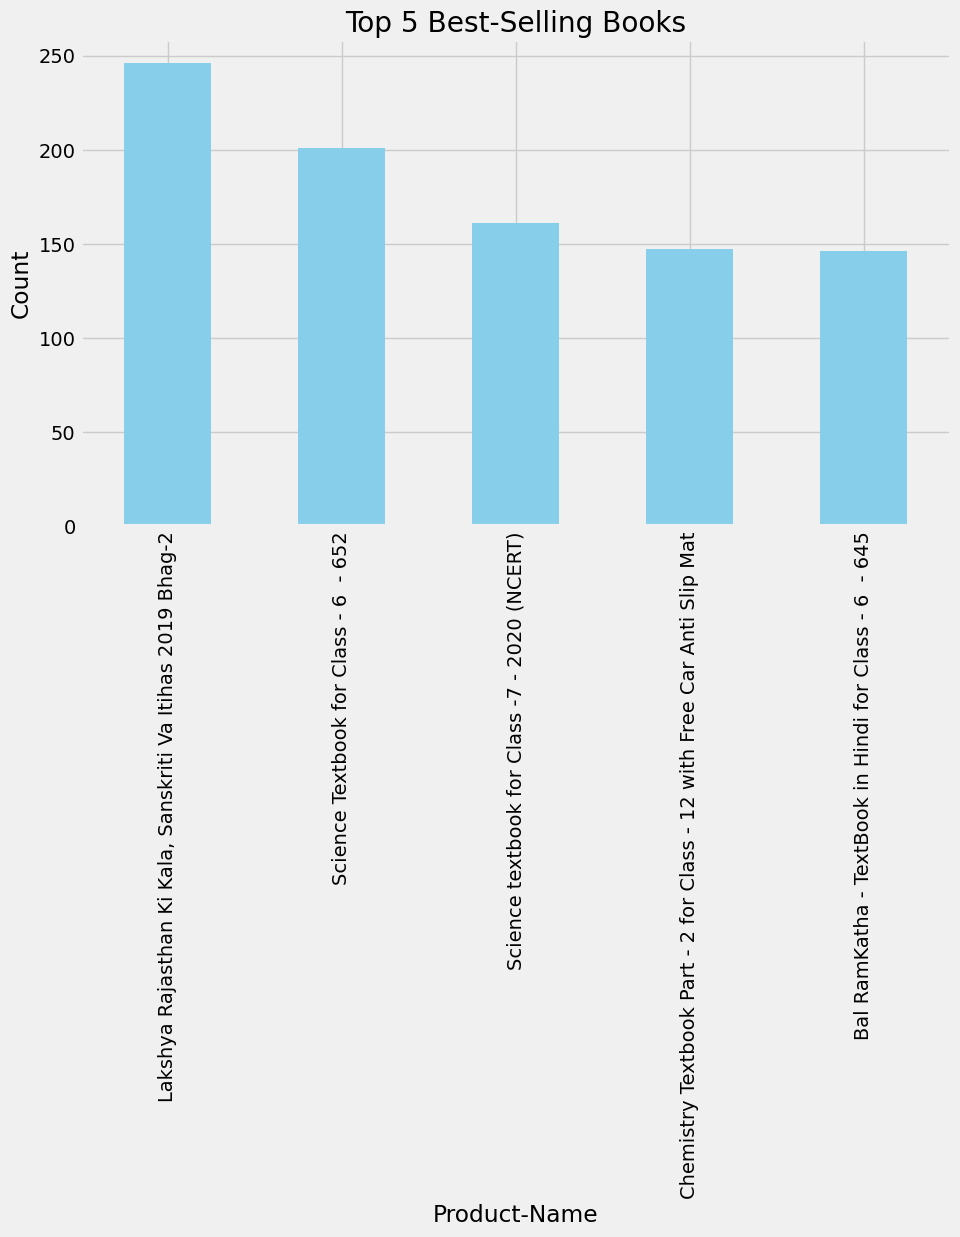

In [ ]:
# creating a bar plot to visualize the distribution of product names (Top 5)
plots.figure(figsize=(10, 6))
name_counts.head(5).plot(kind='bar', color='skyblue')
plots.title('Top 5 Best-Selling Books')
plots.ylabel('Count')
plots.xlabel('Product-Name')
plots.show()

In [22]:
# used to count the occurrences of each unique value in the 'Authors' column
Authors_count = df['Author '].value_counts()
print(Authors_count)

Author 
NCERT                                   1598
MAHAVEER JAIN,ANSHUL JAIN KANTI JAIN     246
Kanti Jain                                72
Multiple Authors                          68
Preeti Agarwal                            66
                                        ... 
Alok Goyal, Mridula Goyal                  1
Stephenie Meyer                            1
T.S. Grewal                                1
vikas purohit                              1
John David Jackson                         1
Name: count, Length: 173, dtype: int64


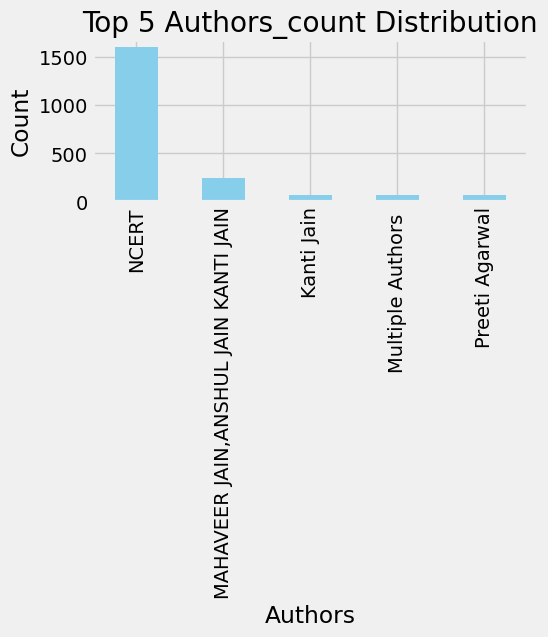

In [25]:
# creating a bar plot to visualize the distribution of Authors
plots.figure(figsize=(5, 2))
Authors_count.plot(kind='bar', color='skyblue')
Authors_count.head(5).plot(kind='bar', color='skyblue')
plots.title('Top 5 Authors_count Distribution')
plots.xlabel('Authors')
plots.ylabel('Count')
plots.show()

In [26]:
# used to count the occurrences of each unique value in the 'category' column
Category_counts = df['Category'].value_counts()
print(Category_counts)

Category
school          1859
competition      847
college          706
Name: count, dtype: int64


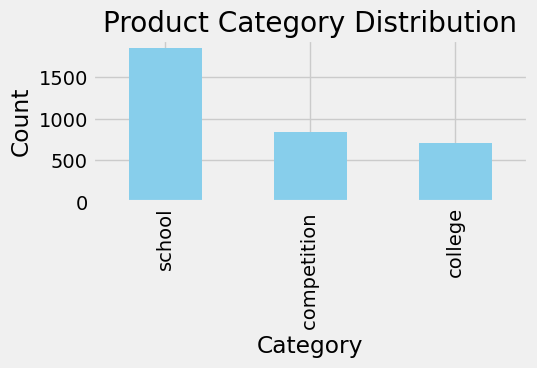

In [ ]:
# creating a bar plot to visualize the distribution of category
plots.figure(figsize=(5, 2))
Category_counts.plot(kind='bar', color='skyblue')
plots.title('Product Category Distribution')
plots.xlabel('Category')
plots.ylabel('Count')
plots.show()

In [ ]:
#To calculate which customer is making the most purchases in order to serve them with targeted offers:
most_Customer = df['Customer ID'].value_counts()
print(most_Customer)


Customer ID
B07FWVUVY    8
B07FWVUVZ    7
B07FWVUWS    7
B07FWVUUU    7
B07FWVXXX    6
            ..
B07FWXSUV    1
B07FWXBRU    1
B07FWXWZS    1
B07FWXZZZ    1
B07FWWSUQ    1
Name: count, Length: 2731, dtype: int64


In [ ]:
#To calculate the rush hours in order to increase the number of employees and better serve customers:
label_counts = df['Morning'].value_counts()

rush_hours_df = pd.DataFrame({
    'Period': label_counts.index,
    'Frequency': label_counts.values
})

# Print the rush hours table
print(rush_hours_df)

  Period  Frequency
0      0       2333
1      1       1079


In [ ]:
most_frequent_buyers = df['ID'].value_counts().head(1).index
df['DeductionEntitlement'] = 0
df.loc[df['ID'].isin(most_frequent_buyers), 'DeductionEntitlement'] = 1
print(df)

        ID        Date      Time Online Sale Offers  Weekend Morning  \
0        1    1/1/2018   8:57 AM                   1       0       1   
1        2    1/2/2018   2:04 AM                   1       0       0   
2        3    1/3/2018   5:08 AM                   1       0       0   
3        4    1/4/2018   4:06 PM                   1       0       0   
4        5    1/4/2018   8:12 PM                   0       0       0   
...    ...         ...       ...                 ...     ...     ...   
3407  3476  12/31/2019  12:02 PM                   1       0       0   
3408  3477  12/31/2019   2:53 AM                   1       0       0   
3409  3478  12/31/2019   6:02 AM                   1       0       1   
3410  3479  12/31/2019   7:28 AM                   1       0       1   
3411  3480  12/31/2019   9:06 AM                   1       0       1   

     Afternoon Evening Night Customer ID  ... Item Price Shipping-Price  \
0            0       0     0   B07FWXWZT  ...      999.0    

In [ ]:
#To calculate which customer is making the most purchases in order to serve them with targeted offers:
most_Customer = df['Customer ID'].value_counts()
print(most_Customer)

Customer ID
B07FWVUVY    8
B07FWVUVZ    7
B07FWVUWS    7
B07FWVUUU    7
B07FWVXXX    6
            ..
B07FWXSUV    1
B07FWXBRU    1
B07FWXWZS    1
B07FWXZZZ    1
B07FWWSUQ    1
Name: count, Length: 2731, dtype: int64


In [ ]:
#To calculate the rush hours in order to increase the number of employees and better serve customers:
periods = df[['Morning','Afternoon','Evening','Night']].apply(pd.Series.value_counts).T[1]
rush_hours_df = pd.DataFrame({
    'Period': periods.index,
    'Frequency': periods.values
})
# Print the rush hours table
print(rush_hours_df)

      Period  Frequency
0    Morning       1079
1  Afternoon        954
2    Evening        598
3      Night        781
